# KBI Convergence

A brief tutorial on evaluating KBI convergence with *KBIntegrator* a given system.

In [1]:
import warnings
from pathlib import Path

from kbkit.kbi import KBIntegrator
from kbkit.systems import SystemProperties

warnings.filterwarnings("always")

### First start with a non-converged example

Demonstrate how to use the different *errors* and *force* arguments.

In [2]:
# create integrator object

system_path = Path("./test_data/size_effects/sys_706").resolve()
sysprop = SystemProperties(system_path)

rdf_path = Path(system_path) / "kbi_rdf_files_50ns"
rdf_files = sorted(rdf_path.glob("*.xvg"))

[f.name for f in rdf_files]

['rdf_ETHOL_ETHOL.xvg', 'rdf_ETHOL_SPCEW.xvg', 'rdf_SPCEW_SPCEW.xvg']

In [3]:
rdf = next(rdf_path.glob("*ETHOL*ETHOL*"))

In [4]:
# create integrator object from rdf file and systemproperties object
# raise_on_convergence_error -> True: raise error; False: print warning & return np.nan
# force -> True: returns approximated KBI value (if convergence fails); False: either raises or prints ConvergenceError

from kbkit.utils.exceptions import KBIConvergenceError

print("Evaluating KBIs for different force/errors args:")
print(60 * "=")
for errors in ("raise", "warn", "ignore"):
    for force in (True, False):
        int_obj = KBIntegrator.from_rdf(rdf, sysprop, errors=errors, force=force)
        try:
            kbi = int_obj.kbi
            print(f"{errors=}, {force=}, {kbi=:.4f}")
        except KBIConvergenceError as e:
            print(f"{errors=}, {force=}, KBIConvergenceError raised: {e}")

Evaluating KBIs for different force/errors args:


/Users/b324115/Library/CloudStorage/Box-Box/critical_phenomena_saxs/allisons_data/pyPkgs/kbkit/src/kbkit/kbi/integrator.py:599: RuntimeWarning: KBI convergence failed: Could not find valid regression window with R^2 > 0.99 (best R^2 = 0.9888). Falling back to weight_type='u2'.
  return self.compute_kbi(weight_type=self.weight_type)


errors='raise', force=True, kbi=-0.0285
errors='raise', force=False, KBIConvergenceError raised: Could not find valid regression window with R^2 > 0.99 (best R^2 = 0.9888).


/Users/b324115/Library/CloudStorage/Box-Box/critical_phenomena_saxs/allisons_data/pyPkgs/kbkit/src/kbkit/kbi/integrator.py:599: RuntimeWarning: KBI convergence failed: Could not find valid regression window with R^2 > 0.99 (best R^2 = 0.9888). Falling back to weight_type='u2'.
  return self.compute_kbi(weight_type=self.weight_type)
/Users/b324115/Library/CloudStorage/Box-Box/critical_phenomena_saxs/allisons_data/pyPkgs/kbkit/src/kbkit/kbi/integrator.py:599: RuntimeWarning: Could not find valid regression window with R^2 > 0.99 (best R^2 = 0.9888).
  return self.compute_kbi(weight_type=self.weight_type)


errors='warn', force=True, kbi=-0.0285
errors='warn', force=False, kbi=nan
errors='ignore', force=True, kbi=-0.0285
errors='ignore', force=False, kbi=nan


/Users/b324115/Library/CloudStorage/Box-Box/critical_phenomena_saxs/allisons_data/pyPkgs/kbkit/src/kbkit/kbi/integrator.py:599: RuntimeWarning: KBI convergence failed: Could not find valid regression window with R^2 > 0.99 (best R^2 = 0.9888). Falling back to weight_type='u2'.
  return self.compute_kbi(weight_type=self.weight_type)


In [5]:
integ = KBIntegrator.from_rdf(rdf, sysprop, errors="warn", force=False)

/Users/b324115/Library/CloudStorage/Box-Box/critical_phenomena_saxs/allisons_data/pyPkgs/kbkit/src/kbkit/kbi/integrator.py:872: RuntimeWarning: Could not find valid regression window with R^2 > 0.99 (best R^2 = 0.9888).
  ax2, color="k", ls=(0, (3, 2)), lw=2.5, label=rf"G$^\infty$={self.compute_kbi('geometric'):.2e}"


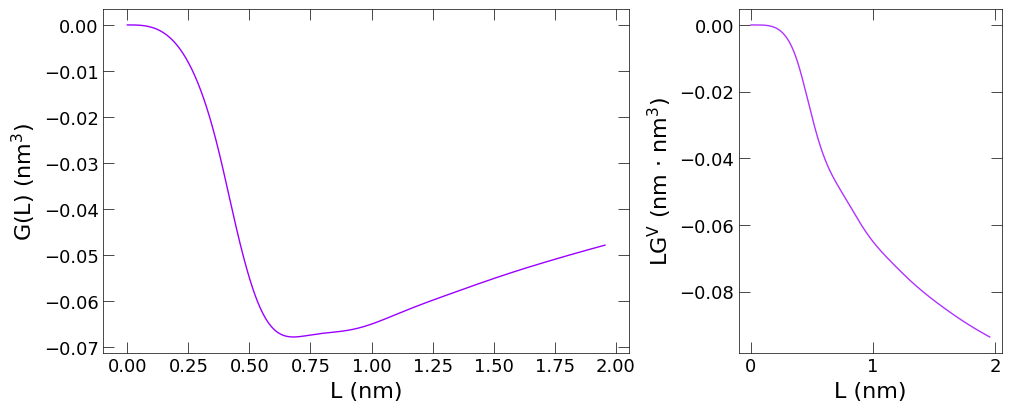

In [6]:
# note that for a non-converged value; there will not be a linear range identified!
integ.plot_kbi_compare_extrapolation(integ.weight_type)

### Using a converged example

In [7]:
# create integrator object

system_path = Path("./test_data/size_effects/sys_406").resolve()
sysprop = SystemProperties(system_path)

rdf_path = Path(system_path) / "kbi_rdf_files_200ns"
rdf_files = sorted(rdf_path.glob("*.xvg"))

[f.name for f in rdf_files]

['rdf_ETHOL_ETHOL.xvg', 'rdf_ETHOL_SPCEW.xvg', 'rdf_SPCEW_SPCEW.xvg']

In [8]:
rdf = next(rdf_path.glob("*ETHOL*ETHOL*"))

In [9]:
# create integrator object from rdf file and systemproperties object
# raise_on_convergence_error -> True: raise error; False: print warning & return np.nan
# force -> True: returns approximated KBI value (if convergence fails); False: either raises or prints ConvergenceError

from kbkit.utils.exceptions import KBIConvergenceError

print("Evaluating KBIs for different force/errors args:")
print(60 * "=")
for errors in ("raise", "warn", "ignore"):
    for force in (True, False):
        int_obj = KBIntegrator.from_rdf(rdf, sysprop, errors=errors, force=force)
        try:
            kbi = int_obj.kbi
            print(f"{errors=}, {force=}, {kbi=:.4f}")
        except KBIConvergenceError as e:
            print(f"{errors=}, {force=}, KBIConvergenceError raised: {e}")

Evaluating KBIs for different force/errors args:
errors='raise', force=True, kbi=-0.0317
errors='raise', force=False, kbi=-0.0317
errors='warn', force=True, kbi=-0.0317
errors='warn', force=False, kbi=-0.0317
errors='ignore', force=True, kbi=-0.0317
errors='ignore', force=False, kbi=-0.0317


In [10]:
integ = KBIntegrator.from_rdf(rdf, sysprop, errors="warn", force=False)

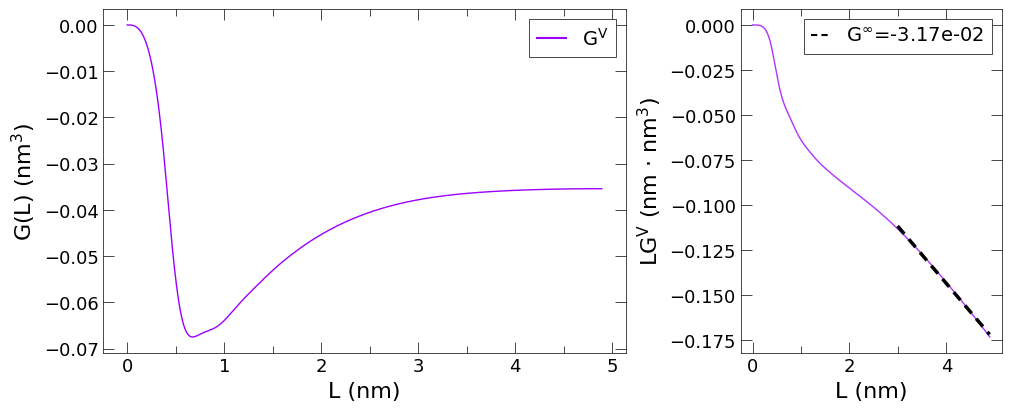

In [11]:
# for a converged example; there is a plateau in G(L) and linear region in LG(L) vs. L
integ.plot_kbi_compare_extrapolation(integ.weight_type)